# Ensemble Models

**Custom Project.** Module 5, Phase 5.

- Author: Tulsi
- Date: 2026-07
- Dataset: insurance.csv (Choi 2018, Kaggle, ODbL v1.0)
- Target: charge_class (four quartile bins of charges)

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## Overview

This project uses the penguins dataset.
We choose to predict the target `sex`.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target)
- an ensemble model because we are choosing to combine approaches to see if we can improve on the classification model in Module 3.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it.

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Voting classifier** - different kinds of models, each fit on the same data; their predictions are combined.

A random forest repeats one model type many times,
and its trees differ because each sees a different random subset
of rows and features.
A voting classifier combines a few different types,
here a decision tree, a support vector machine, and a neural network,
all fit on the same data.
Combining works when the members make different errors,
so those errors partly cancel.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain.

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [11]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05 Project", level="DEBUG")
log_header(LOG, "M05 Project")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-31 21:03:53 | INFO | M05 Project | === RUN START ===
2026-07-31 21:03:53 | INFO | M05 Project | project=M05 Project
2026-07-31 21:03:53 | INFO | M05 Project | repo_dir=ml-05-ensembles
2026-07-31 21:03:53 | INFO | M05 Project | python=3.14.2
2026-07-31 21:03:53 | INFO | M05 Project | os=Windows 11
2026-07-31 21:03:53 | INFO | M05 Project | shell=powershell
2026-07-31 21:03:53 | INFO | M05 Project | cwd=notebooks
2026-07-31 21:03:53 | INFO | M05 Project | github_actions=False
2026-07-31 21:03:53 | INFO | M05 Project | Confirming installation:
2026-07-31 21:03:53 | INFO | M05 Project |   python:       3.14.2
2026-07-31 21:03:53 | INFO | M05 Project |   pandas:       3.0.5
2026-07-31 21:03:53 | INFO | M05 Project |   numpy:        2.5.1
2026-07-31 21:03:53 | INFO | M05 Project |   scikit-learn: 1.9.0
2026-07-31 21:03:53 | INFO | M05 Project |   seaborn:      0.13.2
2026-07-31 21:03:53 | INFO | M05 Project |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [ ]:
# === Section 2. Load and Prepare the Data ===

# CUSTOM: This project loads a real-world CSV from data/raw rather than a
# Seaborn built-in dataset. Medical insurance charges for 1,338 individuals.
# Source: Choi, M. (2018). Medical Cost Personal Datasets. Kaggle. ODbL v1.0.

DATASET_NAME: Final[str] = "insurance"
DATA_PATH: Final[str] = "../data/raw/insurance.csv"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv(DATA_PATH)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")


# === Section 2b. Bin the Continuous Target into Classes ===

# CUSTOM: ANALYST CHOICE - In Module 4 I predicted charges as a continuous
# target using regression. Here I convert charges into four ordered cost
# classes so the same data can be studied as a classification problem.
# I use quartiles so the four classes are balanced and the boundaries come
# from the data itself.

TARGET_COL: Final[str] = "charge_class"
CLASS_LABELS: Final[list[str]] = ["low", "moderate", "high", "very high"]

df_model: pd.DataFrame = df.dropna().copy()
df_model[TARGET_COL] = pd.qcut(df_model["charges"], q=4, labels=CLASS_LABELS)

boundaries = pd.qcut(df_model["charges"], q=4).cat.categories
LOG.info("Quartile boundaries (dollars):")
for label, interval in zip(CLASS_LABELS, boundaries, strict=True):
    LOG.info(f"  {label:10s} {interval.left:>10,.0f} to {interval.right:>10,.0f}")


# === Section 2c. Encode the Categorical Features ===

# CUSTOM: sex, smoker, and region hold text values. One-hot encoding turns
# each into 0/1 columns the models can use. drop_first=True omits one level
# from each, since it is implied by the others being 0.
# charges is EXCLUDED from the features. The target class was derived from it,
# so leaving it in would let the model read off the answer.

NUMERIC_COLS: Final[list[str]] = ["age", "bmi", "children"]
CATEGORICAL_COLS: Final[list[str]] = ["sex", "smoker", "region"]

encoded: pd.DataFrame = pd.get_dummies(
    df_model[CATEGORICAL_COLS], columns=CATEGORICAL_COLS, drop_first=True
)
df_model = pd.concat([df_model, encoded], axis=1)


# === Section 2d. Engineer an Interaction Feature ===

# CUSTOM: ANALYST CHOICE - In Module 4 the smoker-by-bmi interaction was what
# separated a linear model from a polynomial one on this data. Trees can
# represent an interaction through successive splits, but that costs depth.
# Providing the product directly lets a single split capture it.
# I keep both feature sets so the two can be compared directly.

df_model["smoker_bmi"] = df_model["smoker_yes"] * df_model["bmi"]

FEATURE_COLS: Final[list[str]] = NUMERIC_COLS + list(encoded.columns)
FEATURE_COLS_PLUS: Final[list[str]] = FEATURE_COLS + ["smoker_bmi"]

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Base features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
LOG.info(f"Plus features ({len(FEATURE_COLS_PLUS)}): {FEATURE_COLS_PLUS}")
LOG.info(f"Classes in target '{TARGET_COL}': {CLASS_LABELS}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts().sort_index()}")

2026-07-31 21:03:53 | INFO | M05 Project | Loading dataset: insurance
2026-07-31 21:03:53 | INFO | M05 Project | Loaded: 1338 rows (instances), 7 columns
2026-07-31 21:03:53 | INFO | M05 Project | Quartile boundaries (dollars):
2026-07-31 21:03:53 | INFO | M05 Project |   low             1,122 to      4,740
2026-07-31 21:03:53 | INFO | M05 Project |   moderate        4,740 to      9,382
2026-07-31 21:03:53 | INFO | M05 Project |   high            9,382 to     16,640
2026-07-31 21:03:53 | INFO | M05 Project |   very high      16,640 to     63,770
2026-07-31 21:03:53 | INFO | M05 Project | Original rows: 1338
2026-07-31 21:03:53 | INFO | M05 Project | Model rows:    1338
2026-07-31 21:03:53 | INFO | M05 Project | Base features (8): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
2026-07-31 21:03:53 | INFO | M05 Project | Plus features (9): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_sout

## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [13]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

# CUSTOM: The second feature set uses the SAME rows, selected by index,
# so the only difference between the two runs is the added column.
X_train_plus: pd.DataFrame = df_model.loc[X_train.index, FEATURE_COLS_PLUS]
X_test_plus: pd.DataFrame = df_model.loc[X_test.index, FEATURE_COLS_PLUS]

2026-07-31 21:03:53 | INFO | M05 Project | Train instances: 1070
2026-07-31 21:03:53 | INFO | M05 Project | Test instances: 268


## Section 4. Fit and Evaluate a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree, limited to depth 3.
The ensembles are a random forest and a voting classifier.

The analyst must tune their settings (n_estimators, max_depth, ...).
We fit sensible defaults so you can compare them fairly.

Every model is fit twice, once on the base features and once with
smoker_bmi added, so the effect of that one feature can be read directly.

The helper scores train and test separately.
The gap between them is evidence of overfitting.

In [14]:
# === Section 4. Fit and Evaluate the Models ===

# CUSTOM: Helper adapted from the Project 5 example instructions.
# It scores train AND test so the gap between them is visible.
# A large gap is evidence of overfitting: the model fit patterns specific
# to the training rows that do not hold on new data.

results: list[dict] = []


def evaluate_model(
    name: str, model, X_train, y_train, X_test, y_test, features: str
) -> None:
    """Fit a model, score it on train and test, and record the results."""
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")
    acc_gap = train_acc - test_acc
    f1_gap = train_f1 - test_f1

    LOG.info(f"{name} [{features}]")
    LOG.info(
        f"  train accuracy {train_acc:.4f}   test accuracy {test_acc:.4f}   gap {acc_gap:+.4f}"
    )
    LOG.info(
        f"  train F1       {train_f1:.4f}   test F1       {test_f1:.4f}   gap {f1_gap:+.4f}"
    )

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_test_pred, labels=CLASS_LABELS),
        index=CLASS_LABELS,
        columns=CLASS_LABELS,
    )
    LOG.debug(f"Confusion matrix (test), rows = actual:\n{cm}")

    results.append(
        {
            "Model": name,
            "Features": features,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Accuracy Gap": acc_gap,
            "Train F1": train_f1,
            "Test F1": test_f1,
            "F1 Gap": f1_gap,
        }
    )


# === Section 4b. Define and Evaluate the Models ===

# CUSTOM: ANALYST CHOICE - three models, two of them ensembles.
# The single tree is the baseline: one model, depth limited to 3, so the
# ensembles have a simple reference point to be measured against.
# The random forest is a homogeneous ensemble: 200 trees of one type.
# The voting classifier is a heterogeneous ensemble: three different types.
# SVM and the neural net need scaled features, so each is wrapped in a
# pipeline with StandardScaler. The decision tree does not need scaling.


def build_models() -> dict:
    """Return a fresh, unfitted set of the three models."""
    return {
        "single_tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        "random_forest": RandomForestClassifier(
            n_estimators=200, max_depth=10, random_state=RANDOM_STATE
        ),
        "voting": VotingClassifier(
            estimators=[
                ("DT", DecisionTreeClassifier(random_state=RANDOM_STATE)),
                (
                    "SVM",
                    make_pipeline(
                        StandardScaler(),
                        SVC(probability=True, random_state=RANDOM_STATE),
                    ),
                ),
                (
                    "NN",
                    make_pipeline(
                        StandardScaler(),
                        MLPClassifier(
                            hidden_layer_sizes=(50,),
                            max_iter=1000,
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ),
            ],
            voting="soft",
        ),
    }


LOG.info("=== Run 1: base features ===")
for name, model in build_models().items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test, "base")

LOG.info("=== Run 2: base features + smoker_bmi ===")
models_plus = build_models()
for name, model in models_plus.items():
    evaluate_model(
        name, model, X_train_plus, y_train, X_test_plus, y_test, "+smoker_bmi"
    )

results_df: pd.DataFrame = pd.DataFrame(results)
LOG.info(f"Results table:\n{results_df.round(4)}")
results_df.round(4)

2026-07-31 21:03:53 | INFO | M05 Project | === Run 1: base features ===
2026-07-31 21:03:53 | INFO | M05 Project | single_tree [base]
2026-07-31 21:03:53 | INFO | M05 Project |   train accuracy 0.8523   test accuracy 0.8396   gap +0.0128
2026-07-31 21:03:53 | INFO | M05 Project |   train F1       0.8526   test F1       0.8397   gap +0.0130
2026-07-31 21:03:53 | DEBUG | M05 Project | Confusion matrix (test), rows = actual:
           low  moderate  high  very high
low         60         7     0          0
moderate     2        63     2          0
high         2        10    53          2
very high    8         6     4         49
2026-07-31 21:03:54 | INFO | M05 Project | random_forest [base]
2026-07-31 21:03:54 | INFO | M05 Project |   train accuracy 0.9636   test accuracy 0.8619   gap +0.1016
2026-07-31 21:03:54 | INFO | M05 Project |   train F1       0.9632   test F1       0.8599   gap +0.1032
2026-07-31 21:03:54 | DEBUG | M05 Project | Confusion matrix (test), rows = actual:
        

,Model,Features,Train Accuracy,Test Accuracy,Accuracy Gap,Train F1,Test F1,F1 Gap
0,single_tree,base,0.8523,0.8396,0.0128,0.8526,0.8397,0.0130
1,random_forest,base,0.9636,0.8619,0.1016,0.9632,0.8599,0.1032
2,voting,base,0.9495,0.8694,0.0801,0.9487,0.8677,0.0810
3,single_tree,+smoker_bmi,0.8514,0.8358,0.0156,0.8516,0.8358,0.0158
4,random_forest,+smoker_bmi,0.9598,0.8769,0.0829,0.9594,0.8748,0.0846
5,voting,+smoker_bmi,0.9449,0.8731,0.0717,0.9438,0.8713,0.0725


## Section 5. Compare on Held-Out Data## Section 5. Chart the Comparison

The scores were computed in Section 4.
This chart puts the six runs side by side so the effect of adding
smoker_bmi can be read directly.

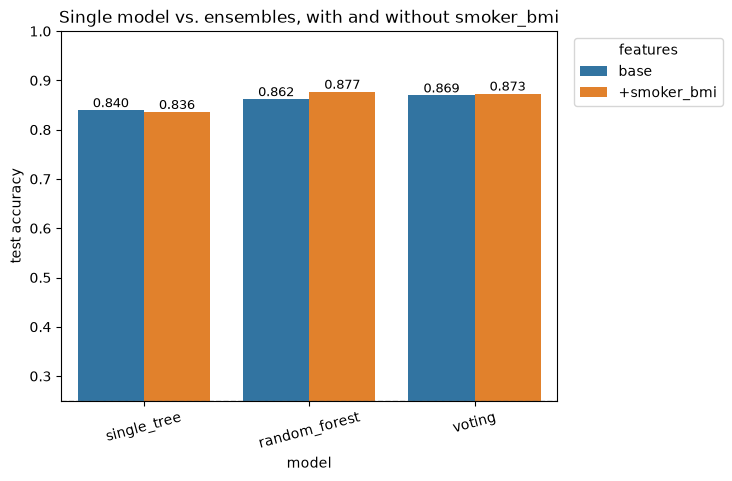

2026-07-31 21:03:56 | INFO | M05 Project | Test accuracy by feature set:
Features       +smoker_bmi    base  change
Model                                     
random_forest       0.8769  0.8619  0.0149
single_tree         0.8358  0.8396 -0.0037
voting              0.8731  0.8694  0.0037
2026-07-31 21:03:56 | INFO | M05 Project | Best model: random_forest [+smoker_bmi] with test accuracy = 0.8769


Features,+smoker_bmi,base,change
Model,,,
random_forest,0.8769,0.8619,0.0149
single_tree,0.8358,0.8396,-0.0037
voting,0.8731,0.8694,0.0037


In [15]:
# === Section 5. Chart the Comparison ===

# The four cost classes are equal in size, so random guessing scores 0.25.
# The y-axis starts there, and the dashed line marks it.

ax = sns.barplot(data=results_df, x="Model", y="Test Accuracy", hue="Features")
plt.ylim(0.25, 1.0)
plt.axhline(0.25, color="gray", linestyle="--", linewidth=1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9)
plt.xlabel("model")
plt.ylabel("test accuracy")
plt.title("Single model vs. ensembles, with and without smoker_bmi")
plt.xticks(rotation=15)
plt.legend(title="features", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig("../docs/images/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

pivot = results_df.pivot(index="Model", columns="Features", values="Test Accuracy")
pivot["change"] = pivot["+smoker_bmi"] - pivot["base"]
LOG.info(f"Test accuracy by feature set:\n{pivot.round(4)}")

best_row = results_df.loc[results_df["Test Accuracy"].idxmax()]
LOG.info(
    f"Best model: {best_row['Model']} [{best_row['Features']}] "
    f"with test accuracy = {best_row['Test Accuracy']:.4f}"
)

pivot.round(4)

### Interpretation

Both ensembles beat the single tree on every measure, on both feature sets.
The best model is the random forest with smoker_bmi at 0.8769 test accuracy,
against 0.8396 for the single tree on the base features. In counts, that is
33 misclassified out of 268 instead of 43, a reduction of ten people placed
in the wrong cost bracket.

The gains are small but consistent, which is what matters more than their size.
Every ensemble beat the baseline every time. Random guessing on four balanced
classes scores 0.25, so all six runs are far above chance.

The engineered smoker_bmi feature helped the ensembles and slightly hurt the
single tree. The forest gained 0.0150 and the voting classifier gained 0.0037,
while the tree lost 0.0038. A tree limited to depth 3 has only three splits to
spend, so a ninth feature changes which three it picks rather than adding
anything.

I cannot answer whether the gain justifies the cost. I can measure the gain.
I have no way to measure what 200 trees cost against one, and no basis for
weighing accuracy against a model I cannot read.

## Section 6. Which Features Did the Forest Rely On?

2026-07-31 21:05:33 | INFO | M05 Project | Random forest feature importances (high to low):
2026-07-31 21:05:33 | INFO | M05 Project |   age                  0.505
2026-07-31 21:05:33 | INFO | M05 Project |   smoker_bmi           0.152
2026-07-31 21:05:33 | INFO | M05 Project |   smoker_yes           0.118
2026-07-31 21:05:33 | INFO | M05 Project |   bmi                  0.106
2026-07-31 21:05:33 | INFO | M05 Project |   children             0.072
2026-07-31 21:05:33 | INFO | M05 Project |   sex_male             0.017
2026-07-31 21:05:33 | INFO | M05 Project |   region_southeast     0.011
2026-07-31 21:05:33 | INFO | M05 Project |   region_southwest     0.010
2026-07-31 21:05:33 | INFO | M05 Project |   region_northwest     0.008


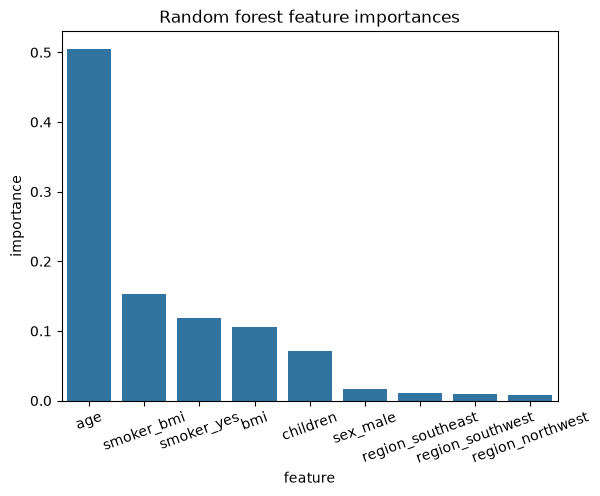

In [17]:
# === Section 6. Feature Importances (Random Forest) ===

"""Chart the random forest's feature importances.

WHY: Ensembles are harder to read than a single tree,
but a forest can still report which features it leaned on.
Importances are a clue, not proof of causation.
"""

forest = models_plus["random_forest"]
importances: np.ndarray = forest.feature_importances_

order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS_PLUS[i]:20s} {importances[i]:.3f}")

plt.figure()
x_values = [FEATURE_COLS_PLUS[i] for i in order]
y_values = importances[order]
sns.barplot(x=x_values, y=y_values)
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")
plt.xticks(rotation=20)
plt.savefig("../docs/images/feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 7. Summary and Next Steps

In [18]:
# === Section 7. Summary ===

LOG.info("=========================")
LOG.info("SUMMARY")
LOG.info("=========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (classification)")
LOG.info(f"Classes: {CLASS_LABELS} (quartiles of charges)")
LOG.info(
    f"Rows: {len(X_train) + len(X_test)} ({len(X_train)} train / {len(X_test)} test)"
)
LOG.info("Compared: single tree vs. random forest vs. voting classifier")
LOG.info("Each fit twice: base features, then with smoker_bmi added")
LOG.info("-------------------------")
LOG.info(f"Test accuracy by feature set:\n{pivot.round(4)}")
LOG.info("-------------------------")
LOG.info(
    f"Best model: {best_row['Model']} [{best_row['Features']}] "
    f"accuracy {best_row['Test Accuracy']:.4f}, F1 {best_row['Test F1']:.4f}"
)
LOG.info(
    f"Baseline for comparison: single tree [base] "
    f"accuracy {pivot.loc['single_tree', 'base']:.4f}"
)
LOG.info(
    f"Top feature:     {FEATURE_COLS_PLUS[order[0]]} ({importances[order[0]]:.3f})"
)
LOG.info(
    f"Weakest feature: {FEATURE_COLS_PLUS[order[-1]]} ({importances[order[-1]]:.3f})"
)
LOG.info("=========================")

2026-07-31 21:07:00 | INFO | M05 Project | =========================
2026-07-31 21:07:00 | INFO | M05 Project | SUMMARY
2026-07-31 21:07:00 | INFO | M05 Project | =========================
2026-07-31 21:07:00 | INFO | M05 Project | Dataset: insurance   Target: charge_class (classification)
2026-07-31 21:07:00 | INFO | M05 Project | Classes: ['low', 'moderate', 'high', 'very high'] (quartiles of charges)
2026-07-31 21:07:00 | INFO | M05 Project | Rows: 1338 (1070 train / 268 test)
2026-07-31 21:07:00 | INFO | M05 Project | Compared: single tree vs. random forest vs. voting classifier
2026-07-31 21:07:00 | INFO | M05 Project | Each fit twice: base features, then with smoker_bmi added
2026-07-31 21:07:00 | INFO | M05 Project | -------------------------
2026-07-31 21:07:00 | INFO | M05 Project | Test accuracy by feature set:
Features       +smoker_bmi    base  change
Model                                     
random_forest       0.8769  0.8619  0.0149
single_tree         0.8358  0.8396 -0.

### Custom Narrative

I changed the target from species to sex. All three models lost accuracy compared with the example, and both ensembles beat the single tree by a wider margin than they did on species, where gradient boosting had no gain at all. The forest relied on bill depth and body mass, the reverse of the species ranking. Body mass carried almost no weight for species at 0.076 and carried the second most for sex at 0.325.

To consider whether the gain is worth the training cost and lost simplicity, I would need some sort of metrics on how we measure and evaluate this. I can measure the gain. I cannot yet measure the cost, because I have not learned how to quantify training time, prediction time or other metrics. I am not sure how to determine the tradeoff. 

### Next Steps

Build a voting classifier combining a decision tree, a support vector machine, and a neural network on the sex target, and compare it against the three models here. Every ensemble in this notebook repeats one model type, while the Project 5 Example instructions include a voting classifier that combines three different types.